In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("joebeachcapital/30000-spotify-songs")

print("Path to dataset files:", path)

Path to dataset files: /Users/wanfranek/.cache/kagglehub/datasets/joebeachcapital/30000-spotify-songs/versions/2


In [7]:
import os
import pandas as pd
import numpy as np

# Find the first CSV file in the downloaded dataset folder
csv_files = []
for root, _, files in os.walk(path):
    for name in files:
        if name.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, name))

if not csv_files:
    raise FileNotFoundError("No CSV files found in the dataset folder.")

csv_path = csv_files[0]
df = pd.read_csv(csv_path)


In [8]:
df.shape

(32833, 23)

In [9]:
df['playlist_genre'].unique()

array(['pop', 'rap', 'rock', 'latin', 'r&b', 'edm'], dtype=object)

In [15]:
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


# Project Proposal:

**Project Title**
What Does a Genre Sound Like?

**Dataset**
Kaggle: "30,000 Spotify Songs" (columns include audio features like danceability, energy, valence, acousticness, tempo, etc.)

source: https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs

**Team Members**
- Edward Z
- Samson W
- Alex T
- Antony M

**Brief Writeup (5-10 lines)**
We want to build a guided tour of six musical genres — EDM, rap, R&B, latin, pop, and rock — that characterizes each one as a distinct personality rather than just a cluster of numbers. The piece opens with a mystery track and asks the reader to guess its genre before revealing the audio-feature profile behind it, using that hook to introduce the idea that genres have measurable sonic fingerprints. From there it widens out: how each genre's scene differs in artist count and album patterns, what track titles reveal as a second signal, and how popularity is distributed within each genre (pop is uniformly popular-ish, while rap shows massive hits and total obscurity side by side). The narrative builds toward an interactive classifier where the reader drags sliders for the main audio features and watches the predicted genre shift in real time. A consistent color palette and a persistent genre selector tie the sections together. One note on the data: `playlist_genre` reflects the playlist a track was pulled from rather than a direct label, so we'll deduplicate by track ID for the cleaner cuts and treat multi-genre tracks as their own small finding.


# Static Visualizations

Histograms of each audio feature

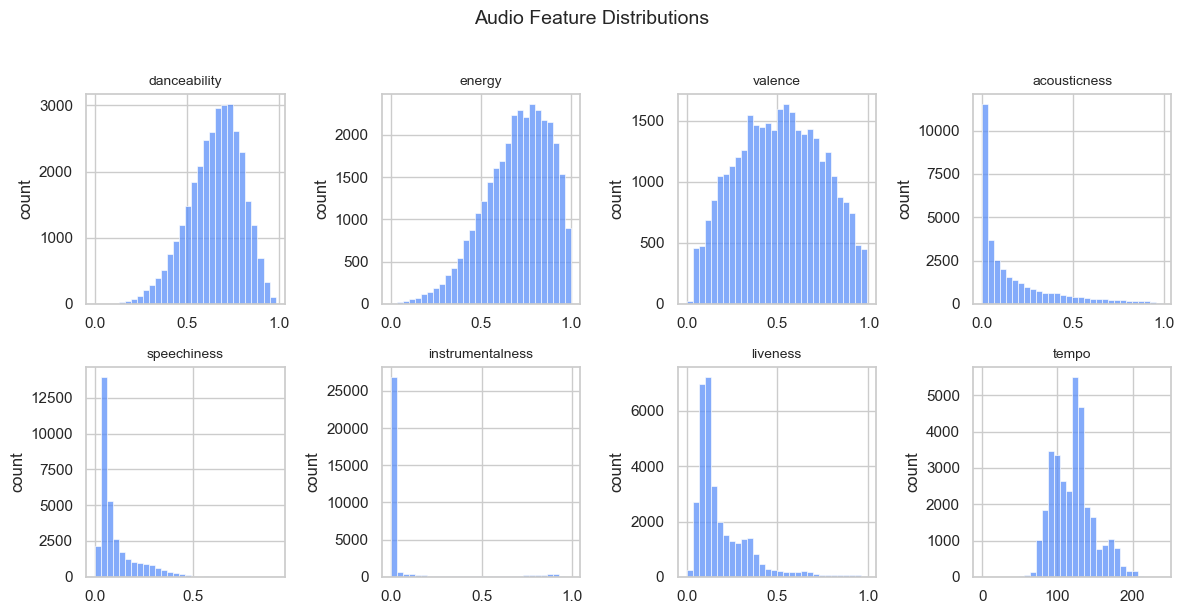

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

hist_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "speechiness",
    "instrumentalness",
    "liveness",
    "tempo",
]

data = df_plot if "df_plot" in locals() else df
data = data.dropna(subset=hist_features)

n_cols = 4
n_rows = int(np.ceil(len(hist_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 6))
axes = axes.ravel()

for i, feature in enumerate(hist_features):
    sns.histplot(data[feature], bins=30, ax=axes[i], color="#5B8FF9")
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("count")

for ax in axes[len(hist_features):]:
    ax.set_visible(False)

fig.suptitle("Audio Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Track count by genre and subgenre

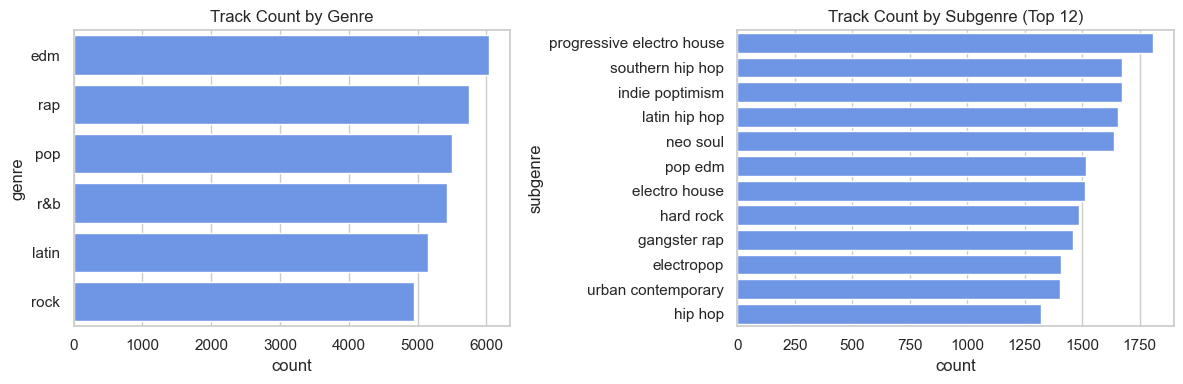

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data = df.dropna(subset=["playlist_genre", "playlist_subgenre"]).copy()
genre_counts = data["playlist_genre"].value_counts()
subgenre_counts = data["playlist_subgenre"].value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[0], color="#5B8FF9")
axes[0].set_title("Track Count by Genre")
axes[0].set_xlabel("count")
axes[0].set_ylabel("genre")

sns.barplot(x=subgenre_counts.values, y=subgenre_counts.index, ax=axes[1], color="#5B8FF9")
axes[1].set_title("Track Count by Subgenre (Top 12)")
axes[1].set_xlabel("count")
axes[1].set_ylabel("subgenre")

plt.tight_layout()
plt.show()

Popularity distribution overall and by genre

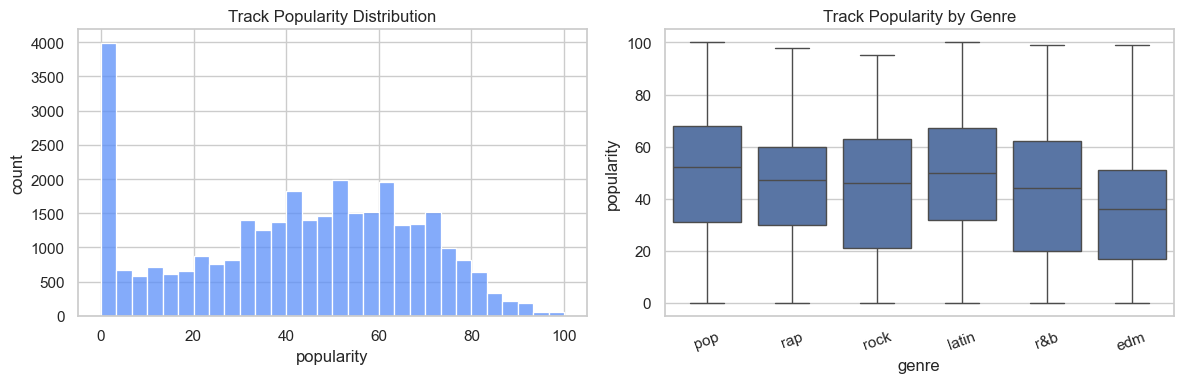

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data = df.dropna(subset=["track_popularity", "playlist_genre"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data["track_popularity"], bins=30, ax=axes[0], color="#5B8FF9")
axes[0].set_title("Track Popularity Distribution")
axes[0].set_xlabel("popularity")
axes[0].set_ylabel("count")

sns.boxplot(data=data, x="playlist_genre", y="track_popularity", ax=axes[1])
axes[1].set_title("Track Popularity by Genre")
axes[1].set_xlabel("genre")
axes[1].set_ylabel("popularity")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Tracks released per year

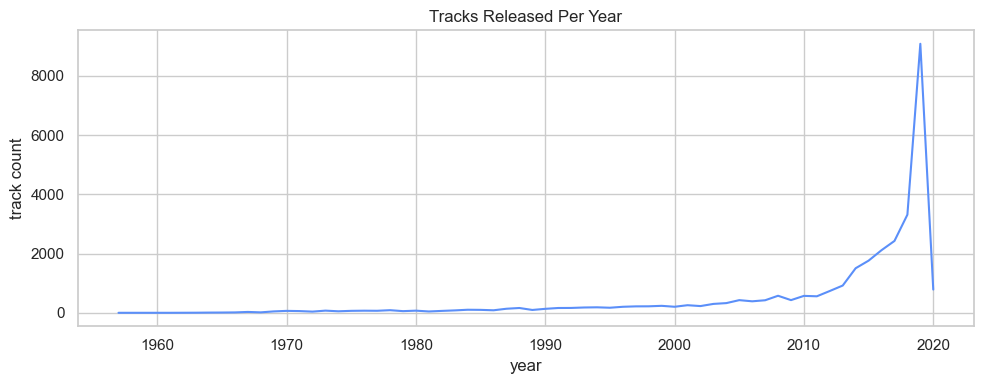

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

dates = pd.to_datetime(df["track_album_release_date"], errors="coerce")
years = dates.dt.year.dropna().astype(int)
year_counts = years.value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.plot(year_counts.index, year_counts.values, color="#5B8FF9")
plt.title("Tracks Released Per Year")
plt.xlabel("year")
plt.ylabel("track count")
plt.tight_layout()
plt.show()

Correlation heatmap of audio features

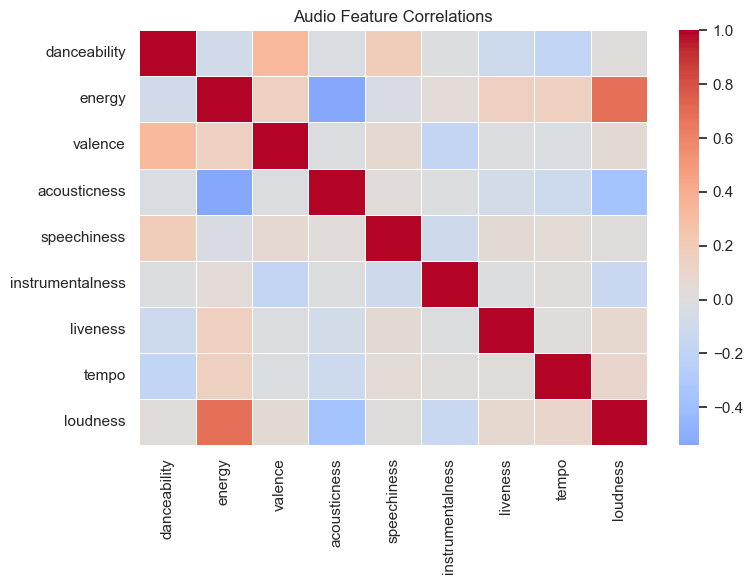

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

corr_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "speechiness",
    "instrumentalness",
    "liveness",
    "tempo",
    "loudness",
]

corr_df = df[corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Audio Feature Correlations")
plt.tight_layout()
plt.show()